# Functions

In [24]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf

import sys
path_to_software_folder = sys.path[0][:-10] + 'software/'
sys.path.append(path_to_software_folder)
from utils import DiffTrajs
from SegEvaluate import *
from SegNet import *

In [25]:
def FixPredictions(prediction, mode='single'):
    "Enforce physical limits on the prediction"
    
    if mode == 'single':
        alphas = prediction[0]
        Ks = prediction[1]
        Ms = np.round(prediction[2])
    elif mode =='batch':
        alphas = prediction[:,0]
        Ks = prediction[:,1]
        Ms = np.round(prediction[:,2])
    
    
    alphas = np.where(alphas > 0, alphas, 0)
    alphas = np.where(alphas < 1.999, alphas, 1.999)
    
    Ks = np.where(Ks > 1e-12, Ks, 1e-12)
    Ks = np.where(Ks < 1e6, Ks, 1e6)
    
    Ms = np.where(Ms > 0, Ms, 0)    
    Ms = np.where(Ms < 3, Ms, 3)
    Ms = np.where(alphas > 1.9, 3, Ms)    # if alpha is over 1.9, M must be 3
    
    if mode == 'single':
        fixed_prediction = np.array([alphas, Ks, Ms])
    elif mode =='batch':
        fixed_prediction = np.stack([alphas, Ks, Ms], axis=1)
    return fixed_prediction

In [26]:
from sklearn import mixture

def AnalyseEnsembleProperties(Data):
    '''
    Returns optimal number of components, along with means and stds.
    '''
    n_components = np.arange(1, 11)[:len(Data)]
    models = [mixture.GaussianMixture(n, covariance_type='diag', tol=0.0001, max_iter=1000, n_init=3).fit(Data)
              for n in n_components]

    BICs = np.zeros(len(n_components))
    for idx, model in enumerate(models):
        BICs[idx] = model.bic(Data) 
        
    best_model_index = np.argmin(BICs)
    best_model = models[best_model_index]
    
    opt_num_components = n_components[best_model_index]
    means = best_model.means_[:,:2]
    stds = best_model.covariances_[:,:2]
    weights = best_model.weights_
    
    return opt_num_components, means, stds, weights, best_model 


def CheckGaussianOverlap(means, covariances, std_scale=1):
    '''
    Checks if any Gaussians mean+- (std_scale) standard deviation(s) contains any other Gaussians' means.
    Returns True is the GMM is good, False if the GMM is bad.
    '''
    standard_deviations = np.sqrt(covariances)

    all_means_min_scaled_std = means - (standard_deviations*std_scale)
    all_means_plu_scaled_std = means + (standard_deviations*std_scale)

    for mean in means:
        others_mask = means != mean
        above_min_mask = all_means_min_scaled_std < mean
        below_max_mask = all_means_plu_scaled_std > mean

        in_std_range_mask = np.logical_and(above_min_mask, below_max_mask)
        other_means_in_std_range = in_std_range_mask[others_mask]

        if np.any(other_means_in_std_range):    # if any of the other Gaussians have means within one std of, this GMM is bad
            return False
    
    return True    # if not, this GMM is good!


def CheckWeights(weights, weight_cutoff=0.05):
    '''
    Checks the values of the weights, removes them if they seem too low
    '''
    return np.all(weights > weight_cutoff)

In [27]:
def PredictAndSplit_M(model, padded_trajs, padding_mask, min_peak_height=0.25):
    '''
    Predict based on all the padded trajectories passed, then split according to paddding mask and the predicted CPs
    '''
    ## Make predictions ##
    Pred_Labs = model.predict(padded_trajs)
    Pred_Labs_M = None #Pred_Labs[2]    # Store the model info
    Pred_Labs = np.concatenate(Pred_Labs[:2], axis=2)    # concatenate the CP data and the alpha k and class data
    ## /Make predictions ##

    ## Split up the segments, keeping track of where each came from ##
    Label_Segments = []    # we will collect all the segments for each traj into this list
    All_CPs = []
    
    for traj_idx, (traj, pred_lab) in enumerate(zip(padded_trajs, Pred_Labs)):
        ## Undo the padding ##
        pred_lab = pred_lab[padding_mask[traj_idx]]
        ## /Undo the padding ##

        CP_labels = pred_lab[:,0]
        alpha_and_K_and_class_each_timestep = pred_lab[:,1:]

        ## Get Changepoints ##
        CPs = LabelToCP(CP_labels, min_peak_height=min_peak_height)
        All_CPs = All_CPs + [np.concatenate((CPs, [np.count_nonzero(padding_mask[traj_idx])]))]    # append lenght as a final CP
        ## /Get Changepoints ##

        ## Split according to changepoitns ##
        pred_label_segments = np.split(alpha_and_K_and_class_each_timestep, CPs)

        ## Save each of these created split segment labels! ##
        Label_Segments = Label_Segments + [pred_label_segments]
        ## /Split according to changepoitns ##
    ## /Split up the segments, keeping track of where each came from ##

    return Label_Segments, All_CPs, Pred_Labs_M

In [28]:
def PhaseOnePredictions(model, weight_path_template, data_path, max_traj_len=200, min_peak_height=0.25):
    '''
    Load all data and make predictions using a U-Net
    '''
    ### Load data and prepare it for network ###
    All_Trajs = []    # stores all the trajs across all exps and fovs!
    All_Padding_Masks = []    # stores all the padding masks across all exps and fovs!
    All_Traj_Addresses = []    # for each traj, stores what exp and fov its from!

    num_exps = len(os.listdir(data_path + '/track_2/'))
    for exp in range(num_exps):
        all_files = os.listdir(data_path + f'/track_2/exp_{exp}/')
        num_fovs = len([fov for fov in all_files if fov.startswith('trajs_fov')])
        for fov in range(num_fovs):
            FOV_df = pd.read_csv(data_path + f'track_2/exp_{exp}/trajs_fov_{fov}.csv')
            FOV = FOV_df.to_numpy()

            num_trajs = int(FOV[-1,0]) + 1
            all_trajs = np.zeros((num_trajs,max_traj_len,2))    # prepare a container for all the trajs
            traj_idx = -1
            padding_mask = np.full((num_trajs,max_traj_len), True)    # keeps track of what is padded vs authentic data

            _, first_idx = np.unique(FOV[:,0], return_index=True)    # split into diff trajs
            split_trajs = np.split(FOV, first_idx[1:])    

            for traj in split_trajs:
                traj_idx += 1
                first_frame, last_frame = int(traj[0,1]), int(traj[-1,1])

                all_trajs[traj_idx][first_frame:last_frame+1] = traj[:,2:4]    # drop in the traj
                all_trajs[traj_idx][:first_frame] = traj[0,2:4]    # pad the traj!
                all_trajs[traj_idx][last_frame+1:] = traj[-1,2:4]

                padding_mask[traj_idx][:first_frame] = False    # keep track of what values are padding
                padding_mask[traj_idx][last_frame+1:] = False

                All_Traj_Addresses = All_Traj_Addresses + [[exp, fov]]

            All_Trajs = All_Trajs + [all_trajs]
            All_Padding_Masks = All_Padding_Masks + [padding_mask]
        
    All_Trajs = np.concatenate(All_Trajs, axis=0) 
    All_Trajs = DiffTrajs(All_Trajs)
    All_Padding_Masks = np.concatenate(All_Padding_Masks, axis=0)        
    All_Traj_Addresses = np.array(All_Traj_Addresses)
    ### /Load data and prepare it for network ###

    ### Loop over each experiment once more, attending to it with the appropriate network ###
    # I know this isn't the most efficient way to do this, its better for compatability
    Label_Segments = []
    All_CPs = []
    # All_Ms = []
    All_Ms = None
    for exp in tqdm(range(num_exps)):
        ### Collect all trajs and padding masks for this experiment ###
        exp_mask = All_Traj_Addresses[:,0] == exp
        exp_Trajs = All_Trajs[exp_mask]
        exp_Padding_Mask = All_Padding_Masks[exp_mask]
        
        ### Load the correct network and apply it 
        weight_path = weight_path_template.replace('#EXP_NUM#', str(exp))
        model.load_weights(weight_path)
        exp_Label_Segments, exp_CPs, exp_Ms = PredictAndSplit_M(model, exp_Trajs, exp_Padding_Mask, min_peak_height=min_peak_height)
        
        ### Save the results for this exp to the master lists
        Label_Segments = Label_Segments + exp_Label_Segments
        All_CPs = All_CPs + exp_CPs
        # All_Ms = All_Ms + exp_Ms
    ### /Loop over each experiment once more, attending to it with the appropriate network ###
    
    return All_Traj_Addresses, Label_Segments, All_CPs, All_Ms, num_exps, num_fovs

In [29]:
def GetModel(exp_model):
    '''
    Convert one hot M prediction to model label
    '''
    models_possible = ['single_state', 'multi_state', 'dimerization', 'confinement', 'immobile_traps']
    model_idx = np.argmax(exp_model)
    return models_possible[model_idx]

In [30]:
def ParabolicWeighting(num_weights, exp=2.0, weighting_agression=1.0, minimum=1.0):
    '''
    Generates positive parabolic weights, with midpoint weighted highest
    '''
    xs = np.linspace(-1,1,num_weights)
    ys = (1-((xs)**exp)) * weighting_agression + minimum
    
    return ys

In [36]:
def PhaseTwoPredictions(All_Traj_Addresses, Label_Segments, CPs, Ms,
                        num_exps, num_fovs,
                        output_name,
                        predict_ensemble_properties=True, 
                        exp_preds=['single_state', 'single_state', 'immobile_traps', 'confinement',
                                   'multi_state', 'multi_state', 'multi_state', 'multi_state', 
                                   'dimerization', 'multi_state', 'single_state', 'immobile_traps']):
    '''
    Take the outputs from phase one and use them to make phase two predictions.
    
    exp_preds come from Generalist network ## todo make the data copy over automatically
    '''    
    if predict_ensemble_properties:
        ALL_EXP_LABELS = []
        # ALL_EXP_MODELS = []
    for exp in tqdm(range(num_exps)):
        ### Collect all segments for this experiment ###
        exp_mask = All_Traj_Addresses[:,0] == exp
        exp_Traj_Addresses = All_Traj_Addresses[exp_mask]
        exp_Labels = [seg_lab for e_mask, seg_lab in zip(exp_mask, Label_Segments) if e_mask]
        exp_CPs = [cp for e_mask, cp in zip(exp_mask, CPs) if e_mask]
        # exp_Ms = [m for e_mask, m in zip(exp_mask, Ms) if e_mask]
        ### Collect all segments for this experiment ###

        ### create the correct file structure ###
        results_dir_path = os.getcwd() + f'/{output_name}/track_2/exp_{exp}/'
        ### /create the correct file structure ###    

        ### If needed, do ensemble level analysis ### 
        if predict_ensemble_properties:
            ### Ensemble Level Analysis! ###
            flat_traj_labels = [np.concatenate(exp_lab, axis=0) for exp_lab in exp_Labels]
            flat_exp_labels = np.concatenate(flat_traj_labels, axis=0)
            ALL_EXP_LABELS = ALL_EXP_LABELS + [flat_exp_labels]
            num_components, means, stds, weights, GMM_model = AnalyseEnsembleProperties(flat_exp_labels)      
            
            # traj_lens = np.array([len(ftl) for ftl in flat_traj_labels])
            # flat_exp_model = np.average(exp_Ms, axis=0, weights=traj_lens**2)
            # ALL_EXP_MODELS = ALL_EXP_MODELS + [flat_exp_model]
            # exp_model = GetModel(flat_exp_model)
            exp_model = exp_preds[exp]

            ### write to file ###
            Path(results_dir_path).mkdir(parents=True, exist_ok=True)
            file = open(results_dir_path + f'ensemble_labels.txt', 'w')
            prediction_string = f'model: {exp_model}; num_state: {num_components} \n'
            prediction_string += "; ".join(means[:,0].astype('str')) + '\n'    # all alpha means
            prediction_string += "; ".join(stds[:,0].astype('str')) + '\n'    # all alpha stds
            prediction_string += "; ".join(means[:,1].astype('str')) + '\n'    # all K means
            prediction_string += "; ".join(stds[:,1].astype('str')) + '\n'    # all K stds
            prediction_string += "; ".join(weights.astype('str'))    # weights
            file.write(prediction_string)
            file.close()
            ### write to file ###  
        ### If needed, do ensemble level analysis ###


        ## loop over all fovs in this experiment and write their info to different files ###
        fovs = np.unique(exp_Traj_Addresses[:,1])
        for fov in fovs:
            ### collect all info for this FOV ###
            fov_mask = exp_Traj_Addresses[:,1] == fov
            fov_Labels = [seg_lab for f_mask, seg_lab in zip(fov_mask, exp_Labels) if f_mask]
            fov_CPs = [cp for f_mask, cp in zip(fov_mask, exp_CPs) if f_mask]
            ### /collect all info for this FOV ###

            ### write to file ###
            Path(results_dir_path).mkdir(parents=True, exist_ok=True)    # make parent dir if needed
            file = open(results_dir_path + f'fov_{fov}.txt', 'w')
            for traj_idx, (Traj_Labels, Traj_CPs) in enumerate(zip(fov_Labels, fov_CPs)):
                prediction_string = str(traj_idx)
                for seg_label, cp in zip(Traj_Labels, Traj_CPs):
                    avgs_seg_labels = np.average(seg_label, weights=ParabolicWeighting(len(seg_label)), axis=0)
                    seg_label =  FixPredictions(avgs_seg_labels)    # convert TS wise prediction to single values
                    prediction_string = (prediction_string + ','  
                                        +str(seg_label[1]) + ','    # Ks 
                                        +str(seg_label[0]) + ','    # alphas
                                        +str(seg_label[2]) + ','    # Ms
                                        +str(cp))
                prediction_string = prediction_string + '\n'
                file.write(prediction_string)
            file.close()
            # /write to file ###
        ## loop over all fovs in this experiment and write their info to diff files ###     

    if predict_ensemble_properties:
        return ALL_EXP_LABELS#, ALL_EXP_MODELS

In [37]:
def Gauss(mean, std, x):
    return 1/std*np.sqrt(2*np.pi) * np.exp(-0.5 * ((x-mean)**2/std**2))    

# Main

### Build the Network 

In [35]:
import numpy as np
import sys
import tensorflow as tf
from UNet3P_var import *
from UNet_Blocks import *
from utils import DiffTrajs

# Make the model
max_traj_len = 224
filters = [16, 32, 64, 64, 128, 128]

ConvBlockParams = {'num_filters': 128,
                   'kernel_size': 3,
                   'strides': 1,
                   'padding': 'same'}

SkipBlockParams = {'num_filters': 512,
                   'kernel_size': 3,
                   'strides': 1,
                   'padding': 'same'}

DecoderBlockParams = {'num_filters': 512,
                      'kernel_size' :3,
                      'strides': 1,
                      'padding': "same"}

model = UNet3P_var(filters, ConvBlockSimple, ConvBlockParams, SkipBlockParams, DecoderBlockParams, input_len=max_traj_len)

In [50]:
# Model Weights Path template
weight_path_template = sys.path[0][:-10] + 'ChallengeNets/ExperimentSpecificNets/ExpNet_#EXP_NUM#/Model.weights.h5'

### Apply Network to Challenge Data

In [48]:
data_path = sys.path[0][:-10] + '/public_data_challenge_v0/'
output_name_template = "/ExperimentSpecificNets_Predictions/"

In [51]:
All_Traj_Addresses, Label_Segments, All_CPs, Ms, num_exps, num_fovs = PhaseOnePredictions(model, weight_path_template, data_path, max_traj_len=max_traj_len)

  0%|          | 0/12 [00:00<?, ?it/s]

32/32 [==============================] - 15s 465ms/step


  8%|▊         | 1/12 [01:02<11:24, 62.21s/it]

32/32 [==============================] - 15s 464ms/step


 17%|█▋        | 2/12 [01:43<08:20, 50.05s/it]

...

 83%|████████▎ | 10/12 [11:52<02:28, 74.41s/it]

49/49 [==============================] - 23s 464ms/step


 92%|█████████▏| 11/12 [13:05<01:13, 73.83s/it]

57/57 [==============================] - 26s 463ms/step


100%|██████████| 12/12 [13:56<00:00, 69.72s/it]


In [52]:
output_name_nosegnet = output_name_template

All_Traj_Addresses_a = All_Traj_Addresses.copy()
Label_Segments_a = Label_Segments.copy()
All_CPs_a = All_CPs.copy()
Ms_a = Ms

labs = PhaseTwoPredictions(All_Traj_Addresses_a, Label_Segments_a, All_CPs_a, Ms_a, num_exps, num_fovs,
                                 output_name=output_name_nosegnet)

 58%|█████▊    | 7/12 [21:51<15:36, 187.36s/it]


KeyboardInterrupt: 

In [380]:
for i in range(12):
    exp_mask = All_Traj_Addresses[:,0] == i
    exp_Traj_Addresses = All_Traj_Addresses[exp_mask]
    exp_Labels = [seg_lab for e_mask, seg_lab in zip(exp_mask, Label_Segments) if e_mask]
    exp_CPs = [cp for e_mask, cp in zip(exp_mask, All_CPs) if e_mask]

    print(np.mean([len(cps) for cps in exp_CPs]))

1.019019019019019
1.0327706057596822
1.5703012912482066
1.406837606837607
1.7174149448500855
1.1800450112528131
1.241724403387221
1.831413254248888
1.05762987012987
1.4394299287410925
1.012853470437018
5.1948123620309055


Experiment 0
0.852752218991389 0.05525011602038296 1.0


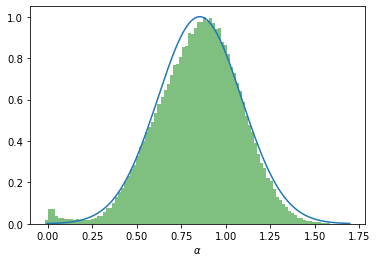

0.21261150264310652 0.03959936161350299 1.0


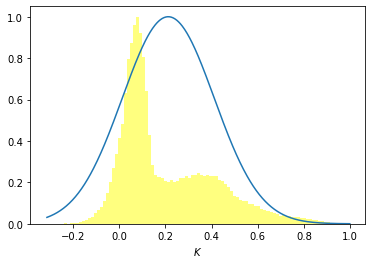

Experiment 1
0.8515694693815156 0.052751306441195384 1.0


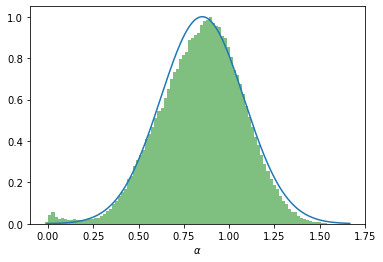

0.21299060000408598 0.03918644292534813 1.0


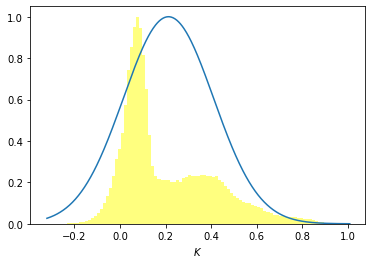

Experiment 2
0.9920598323458252 0.023250882958682134 0.6510537158697273
0.025952140164265777 0.0010641708605504624 0.15053801626478214
1.1206969695128506 0.030850055379995606 0.14399700799592485
0.848579012850326 0.028393649682571825 0.05441125986955029


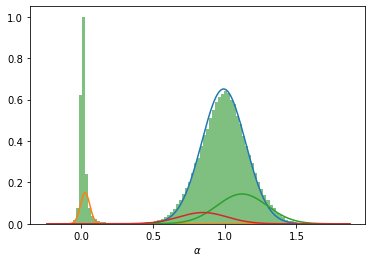

1.036606011148184 0.12662511664517004 0.6510537158697273
0.013657693849674957 0.0006958382916860161 0.15053801626478214
1.613063135728018 0.2611206426107205 0.14399700799592485
0.8366596381134735 0.1274367528734219 0.05441125986955029


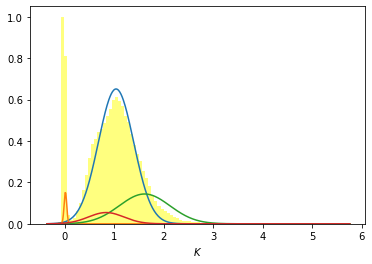

Experiment 3
0.8572186142331952 0.06774096242168612 0.5697260070582592
0.07043285292648264 0.0050195383230302835 0.11843713238233379
0.5667540853746595 0.03836990606534116 0.311836860559407


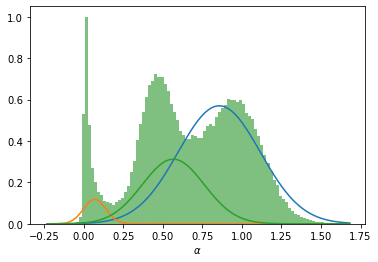

0.8201112848919767 0.36187231535386294 0.5697260070582592
0.011096722375423324 0.0008403034064466744 0.11843713238233379
0.23172280057530678 0.08720015457488807 0.311836860559407


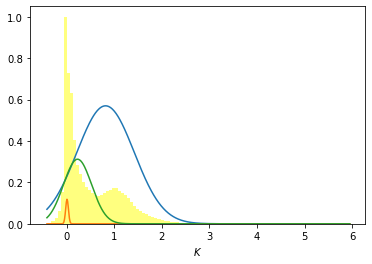

Experiment 4
0.6708480220097386 0.03844778105608129 0.22842436941620672
0.9767873970852545 0.035816182201385466 0.6833683313071348
0.06979652232284664 0.005612527316980147 0.08820729927665842


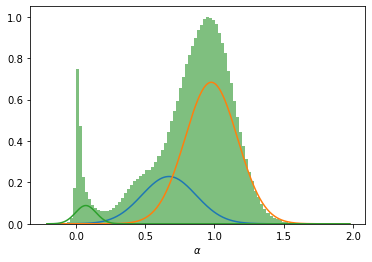

0.31497808223812845 0.13460437649778653 0.22842436941620672
1.0601869852188281 0.29134283427282376 0.6833683313071348
0.012809319210982134 0.0009852862658293678 0.08820729927665842


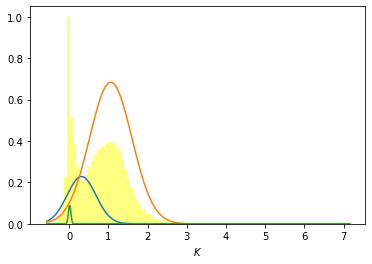

Experiment 5
1.0117014215809013 0.015379938760682636 1.0


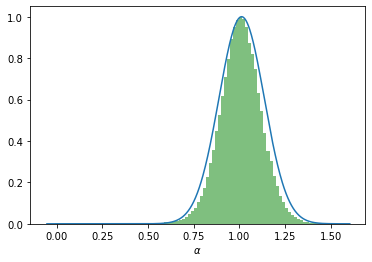

0.5543056669906783 0.08173305904427955 1.0


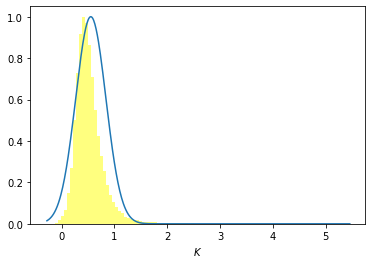

Experiment 6
0.9529676501030914 0.025731908543130316 1.0


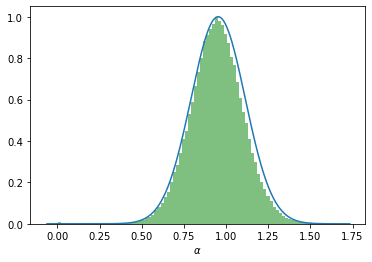

0.5093347946799158 0.10862001463493295 1.0


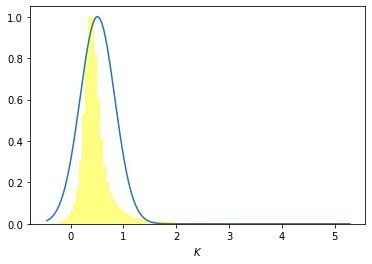

Experiment 7
0.5267719765879856 0.12371713200715881 0.17606074756309142
1.357484720104798 0.04904856211653383 0.10694393449961909
0.9415272376241356 0.05931531119145114 0.7169953179372901


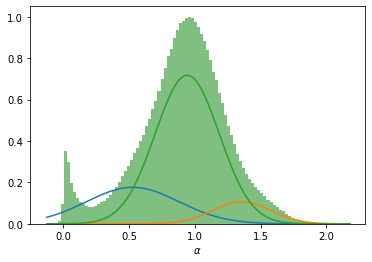

0.12921478257841273 0.03195229726784342 0.17606074756309142
0.5830135135954003 0.055122694606936 0.10694393449961909
0.28742987918804963 0.0157960097304555 0.7169953179372901


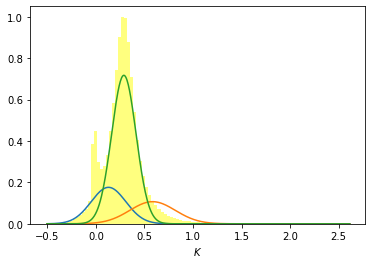

Experiment 8
0.797435599145603 0.09558414752162389 1.0


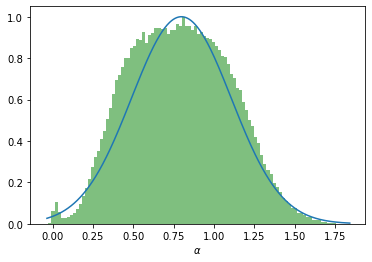

0.483133568343427 0.1485947912338855 1.0


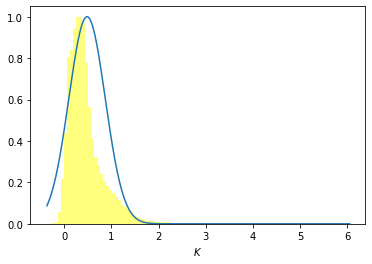

Experiment 9
0.7134501093457325 0.05289082749953819 0.5058996040333927
0.9676005191105703 0.07754546601062037 0.4941003959666067


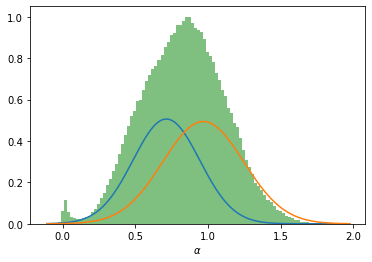

0.4428566904571724 0.07774144871633634 0.5058996040333927
0.7798111589092304 0.3764833881994956 0.4941003959666067


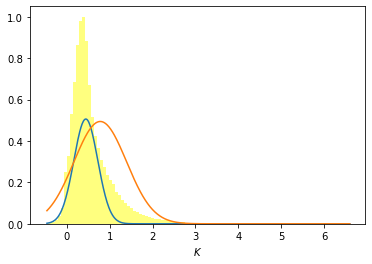

Experiment 10
0.76304665205403 0.2668924946260908 1.0


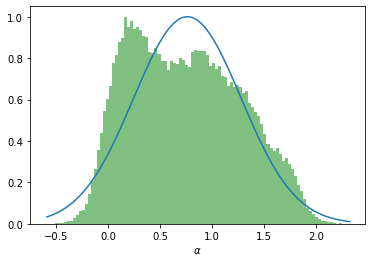

7.213253642244644 22.94990429523175 1.0


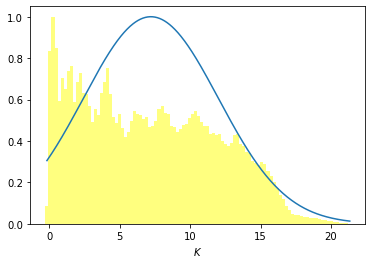

Experiment 11
1.7547429385743691 0.021972642301966466 0.6696117406343731
0.0691264556729307 0.007898811487594633 0.249879903016419
0.9666466368805869 0.12035545042004756 0.08050835634921032


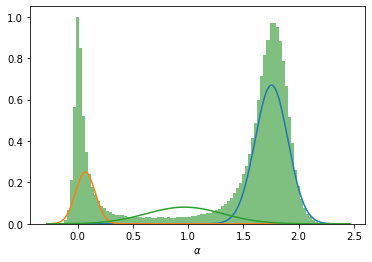

2.049060839336751 0.6171979526958492 0.6696117406343731
0.03761874730815797 0.002101509530336526 0.249879903016419
0.7044291945968417 0.26934366809927907 0.08050835634921032


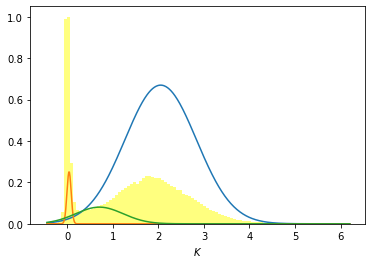

In [340]:
all_labs = labs

for exp_num in range(12):
    print(f'Experiment {exp_num}')
    
    # Evaluate GMM #
    _, means, stds, weights, _ = AnalyseEnsembleProperties(all_labs[exp_num])    
    
    counts, bins = np.histogram(all_labs[exp_num][:,0], bins=100, density=True)
    counts = counts/np.max(counts)
    plt.bar(bins[:-1], counts, width=bins[1]-bins[0], alpha=0.5, color='green')
    for mean, std, weight in zip(means, stds, weights):
        print(mean[0], std[0], weight)
        xs = np.linspace(np.min(all_labs[exp_num][:,0]), np.max(all_labs[exp_num][:,0]), 500)
        ys = Gauss(mean[0], np.sqrt(std[0]), xs)
        ys = weight*(ys/np.max(ys))
        plt.plot(xs, ys)
    plt.xlabel(r'$\alpha$')
    plt.show()
    
    counts, bins = np.histogram(all_labs[exp_num][:,1], bins=100, density=True)
    counts = counts/np.max(counts)
    plt.bar(bins[:-1], counts, width=bins[1]-bins[0], alpha=0.5, color='yellow')
    for mean, std, weight in zip(means, stds, weights):
        print(mean[1], std[1], weight)
        xs = np.linspace(np.min(all_labs[exp_num][:,1]), np.max(all_labs[exp_num][:,1]), 500)
        ys = Gauss(mean[1], np.sqrt(std[1]), xs)
        ys = weight*(ys/np.max(ys))
        plt.plot(xs, ys)
    plt.xlabel(r'$K$')
    plt.show()

In [342]:
models_possible = ['single_state', 'multi_state', 'dimerization', 'confinement', 'immobile_traps']

for i, m in enumerate(mods):
    pred = GetModel(m)
    print(pred)
    print(m)

immobile_traps
[0.16117153 0.14161804 0.05107946 0.21018401 0.43594694]
immobile_traps
[0.1625295  0.14430331 0.05242813 0.21121288 0.42952616]
immobile_traps
[0.18176274 0.0579032  0.08979704 0.21189195 0.45864504]
confinement
[0.10485281 0.07815232 0.08690428 0.60100197 0.12908861]
confinement
[0.09975913 0.15094564 0.11938397 0.4719989  0.15791236]
confinement
[0.05705442 0.02014488 0.04766432 0.83793703 0.03719934]
confinement
[0.03257005 0.03667861 0.05649743 0.85650601 0.01774789]
confinement
[0.08108874 0.054247   0.17833851 0.51566446 0.17066127]
confinement
[0.16342976 0.08106234 0.1922262  0.39632979 0.16695191]
confinement
[0.03495411 0.09885766 0.10538    0.72704211 0.03376611]
single_state
[0.32823638 0.09038809 0.23312723 0.20343013 0.14481816]
immobile_traps
[0.01952355 0.01788816 0.02146192 0.00480703 0.93631931]


### Truth:

immobile traps

single state

multi_state

dimerization

confinement

In [339]:
models_possible = ['single_state', 'multi_state', 'dimerization', 'confinement', 'immobile_traps']

rights = 0
trues = []
preds = []
for i, m in enumerate(mods):
    idx = i % 5
    pred = GetModel(m)
    true = models_possible[idx]
    if pred==true:
        rights += 1
    
    trues = trues + [true]
    preds = preds + [pred]
        
print(100 * rights/300)

1.0


In [331]:
pred_where_true_is_ms = preds[[t == 'multi_state' for t in trues]]

TypeError: list indices must be integers or slices, not list

In [330]:
pred_where_true_is_ms

'single_state'

In [313]:
import sklearn.metrics

In [317]:
cm = sklearn.metrics.confusion_matrix(trues, preds)

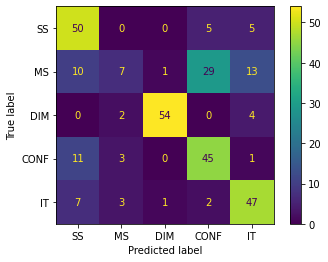

In [323]:
models_possible = ['SS', 'MS', 'DIM', 'CONF', 'IT']

disp = sklearn.metrics.ConfusionMatrixDisplay(cm, display_labels=models_possible)
disp.plot()
plt.show()

In [287]:
print('SS | MS | DIM | Conf| IT')
print('---------------------')
for m in mods:
    print(m)
    print(GetModel(m))
    print()

SS | MS | DIM | Conf| IT
---------------------
[0.24653312 0.08944803 0.11187668 0.18988721 0.36225495]
immobile_traps

[0.35577234 0.10532038 0.15660832 0.30916934 0.07312961]
single_state

[0.07378967 0.31380097 0.1589073  0.39143487 0.06206718]
confinement

[0.20917379 0.13819627 0.14067531 0.44555118 0.06640343]
confinement

[0.24134018 0.08417654 0.18172507 0.42112202 0.07163617]
confinement



### Apply Network to Local Data

In [79]:
use_seg_nets = True

#### Local Eval

In [80]:
data_path = '/home/cs-solomon.asghar/AnDi_2024/Evaluation/LocalEval/ref/'
output_name_template = "/LocalEval/res/"

In [81]:
All_Traj_Addresses, Segments_by_Size, Segment_Addresses_by_Size, CPs, num_exps, num_fovs = PhaseOnePredictions(data_path, max_traj_len=max_traj_len)

517/517 [==============================] - 240s 462ms/step


In [86]:
output_name_nosegnet = output_name_template
PhaseTwoPredictions(All_Traj_Addresses, Segments_by_Size, Segment_Addresses_by_Size, CPs,
                    num_exps, num_fovs,
                    output_name=output_name_nosegnet, use_seg_nets=use_seg_nets, local_eval_mode=True)

100%|██████████| 199/199 [02:46<00:00,  1.20it/s]


##### Starting Kit Eval

In [87]:
data_path = '/home/cs-solomon.asghar/AnDi_2024/Evaluation/StartingKitEval/ref/'
output_name_template = "/StartingKitEval/res/"

In [88]:
All_Traj_Addresses, Segments_by_Size, Segment_Addresses_by_Size, CPs, num_exps, num_fovs = PhaseOnePredictions(data_path, max_traj_len=max_traj_len)

149/149 [==============================] - 70s 468ms/step


In [89]:
output_name_nosegnet = output_name_template
PhaseTwoPredictions(All_Traj_Addresses, Segments_by_Size, Segment_Addresses_by_Size, CPs, 
                    num_exps, num_fovs,
                    output_name=output_name_nosegnet, use_seg_nets=use_seg_nets)

100%|██████████| 199/199 [02:41<00:00,  1.23it/s]
